In [1]:
import json
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
sns.set_style("whitegrid")

original_run_path = "../../Results/Regular_pile_pile_BS16_ValBS16_LR0.0006_Warm2000_adamw_Seed42_results.json"
filtered_run_path = "../../Results/Regular_pile_pile_BS16_ValBS16_LR0.0006_Warm2000_adamw_Seed42_Filtered_results.json"


def load_loss_data(json_path):
    """Loads step and test_loss from a given JSON result file."""
    if not os.path.exists(json_path):
        print(f"Warning: File not found at {json_path}")
        return [], []

    with open(json_path, "r") as f:
        data = json.load(f)

    steps = [entry["step"] for entry in data]
    losses = [entry["test_loss"] for entry in data]
    return steps, losses

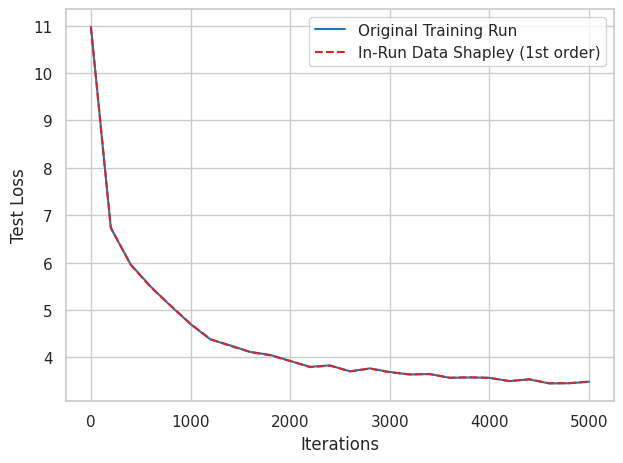

In [2]:
steps_orig, loss_orig = load_loss_data(original_run_path)
steps_filt, loss_filt = load_loss_data(filtered_run_path)

plt.figure()

plt.plot(
    steps_orig[:26], loss_orig[:26], label="Original Training Run", color="#1f77b4"
)

plt.plot(
    steps_filt,
    loss_filt,
    label="In-Run Data Shapley (1st order)",
    color="#d62728",
    linestyle="--",
)

plt.xlabel("Iterations")
plt.ylabel("Test Loss")
plt.legend()

plt.tight_layout()
plt.show()